In [1]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def propensity1(k, x, y):
    '''Calculate the propersity of a reaction with two reactants
    
    parameters
    ----------
    k:int
      reaction constant
    x:int
      molecular number of first reactant
    y:int
      molecular number of first reactant
      
    Returns
    -------
    out: int
       propensity of a reaction
    '''
    return k*x*y

def propensity2(k, x):
    '''Calculate the propersity of a reaction with one reactant
    
    parameters
    ----------
    k:int
      reaction constant
    x:int
      molecular number of reactant
      
    Returns
    -------
    out: int
       propensity of a reaction
    '''
    return k*x


def reaction1(x,y,z):   #reaction 1,2,5: X+Y->Z
    '''Calculate the molecular number change of reaction type 1:X+Y->Z 
       (two reactants and one product)
    
    parameters
    ----------
    x:int
      molecular number of first reactant
    y:int
      molecular number of second reactant
    z:int
      molecular number of first product
      
    Returns
    -------
    out: int
       molecular numbers of reactants and product after the reaction has occurred once
    '''
    if x>0 and y>0:
        x, y, z = x-1,y-1,z+1
    return x, y, z


def reaction2(a, d, e=0):   #reaction 3: a+b->c+d
    '''Calculate the molecular number change of reaction type 2:A+E->E+D
       (two reactants and two products, but one of the reactants is also the product)
    
    parameters
    ----------
    a:int
      molecular number of first reactant
    d:int
      molecular number of second reactant
    e:
      molecular number of the chemical which both appears in reactant and product
      
    Returns
    -------
    out: int
       molecular numbers of reactants and products after the reaction has occurred once 
       (value will not change after reaction)
    '''
    if a>0:
        a, d, e = a-1, e, d+1
    return a, e, d


def reaction3(e,f,g):   #reaction 4: E->F+G
    '''Calculate the molecular number change of reaction type 3:E->F+G
       (one reactant and two products)
    
    parameters
    ----------
    e:int
      molecular number of reactant
    f:int
      molecular number of first product
    g:int
      molecular number of second product
      
    Returns
    -------
    out: int
       molecular numbers of reactants and products after the reaction has occurred once
    '''
    if e>0:
        e, f, g = e-1,f+1,g+1
    return e,f,g
    
    
def firstreaction(a,b,c,d,e,f,g,k1=0,k2=0,k3=0,k4=0,k5=0):
    '''Use the First Reaction Method to simulate one reaction step of the system with 5 reactions in Gibson et al 
    
    parameters
    ----------
    a~g:int
      molecular number of all the 7 chemicals (A~G) involved in the 5 reactions
    k1~k5:int
      reaction constants of 5 chemical reactions (values will not change as reaction occur)
      
    Returns
    -------
    out: tuple with 3 elements
       first element: list
            update the No. of each species after one step
       second element: float
            update the time after one step
       third element: list
            update the propensity of each reaction after one step
    '''        
    prop1=propensity1(k1,a,b)        
    prop2=propensity1(k2,b,c)
    prop3=propensity1(k3,d,e)
    prop4=propensity2(k4,f)
    prop5=propensity1(k5,e,g)      # calculate the propensity of reaction 1~5
    
    prop_list=[prop1,prop2,prop3,prop4,prop5]  # store the propensity of reaction 1~5
    tau_list=[]                                # will be used to store the putative reaction time tau
    
    for i in prop_list:                        # use propensity to calculate the putative time of each reaction
        if i == 0:                             # propensity==0, reaction will never occur, store a infinite no. in tau_list
            tau_list.append(np.inf)
        else:                                  # propensity!=0, calculate the putative time and store it in tau_list
            tau_list.append(((1/i)*np.log(1/(1-np.random.random()))))
    
    if prop_list:                    # if prop_list!=[0,0,0,0,0], which  means system does not reach equilibrium,  choose which
        tau= min(tau_list)           # reaction will occur according to tau (the reaction with minimal tau will occur). 
        u=np.argmin(tau_list)
    
        if u==0:
            a,b,c = reaction1(a,b,c)
        elif u==1:
            b,c,d = reaction1(b,c,d)
        elif u==2:
            d,e,f = reaction2(d,f,e)
        elif u==3:
            f,d,g = reaction3(f,d,g)
        else:
            e,g,a = reaction1(e,g,a)   # update the no. of moleculars to reflect the execution of selected reaction
    
        species_list=[a,b,c,d,e,f,g]
    
        return species_list, tau, prop_list
    return                            # return NoneType if prop_list==[0,0,0,0,0]
   

def window(t1,t2,t1_list, n):
    '''Calculate the index of first element in reaction occurrance time list 
        between each certain time intervals from t1 to t2
    
    parameters
    ----------
    t1: int
      initial time
    t2: int
      ending time
    t1_list: list
      store the reaction occurance time during the stimulation
    n: int
      how many even time intervals we would like to get from t1 to t2
    
    Returns
    -------
    out: list
       the index of the first element in reaction occurrance time list between each 
       certain time intervals from t1 to t2
    '''

    t_list=np.linspace(t1,t2,n)    # divide the time period from t1 to t2 into n time intervals evenly
    
    index_x = []                    
    for j in range(len(t_list)-1):
        elements_between = []
        for i in range(len(t1_list)):
            if t1_list[i]>=t_list[j] and t1_list[i]<t_list[j+1]: # find the indexes of all elements in t1_list between two time 
                elements_between.append(i)                      # intervals in t_list
        if len(elements_between)>0:             # if there are elements in t1_list between two time intervals in t_list, then 
            index_x.append(elements_between[0]) # put the index of the first element in index_x (i.e. the first element in
                                                # list elements_between)
    return index_x

In [3]:
t1=1             # stimulation starting time 
t0=t1            # use t0 to store the initial value of t1
t2=100           # simulation ending time
t1_list=[]          # will be used to store the updating t1(reaction progressing time) after each while loop
chemical_list=[]    # will be used to store the specieslist(list storing molecular no. of species A~G) after each while loop
a,b,c,d,e,f,g = 6,14,8,12,9,3,5  # give the intitial value of A~G

while t1 < t2:
    x=firstreaction(a,b,c,d,e,f,g,k1=1,k2=2,k3=3,k4=4,k5=5)  # start the stimulation
    if x:                                # when the result of stimulation is not NoneType (which means the not all propensities
        a,b,c,d,e,f,g=x[0]               # are 0), the system does not reach equilibrium, update molecular No. of each chemical
        t1+=x[1]                         # as well as t1 after a reaction has been executed
        t1_list.append(t1)               # store the updated t1 in t1_list and store the specieslist(list storing molecular No.
        chemical_list.append(x[0])       # of species A~G) of each while loop in chemical_list 
    #         print(x[2])
        if x[2] == [0, 0, 0, 0, 0]:      # all of the propensities are 0, the system reach equilibrium
            print('System Equilibrium time:',t1_list[-2])  # for the last one is infinite No., get the second-last element in
                                                           # t1_list as the equilibrium time. For t1 plus a infinite No. in last
                                                     # while loop, which is bigger than t2, the while loop has been terminated.  
t = (t2 - t1_list[-2])/100
t1_list = t1_list[:-1] + [(t*i + t1_list[-2]) for i in range(101)]       # when the system reach equilibrium, all the molecular 
chemical_list = chemical_list + [chemical_list[-1] for i in range(100)]  # No. of chemicals would remain the same, then add 
                                                                         # another 100 points for the time period from 
                                                                         # equilibrium time t2 for folllowing figure plotting.
# print(t1_list[-101])        
w=window(t0,t1_list[-101],t1_list, 100)     # the period from initial time to equilibrium time was divided into 100              
for i in w:                                 # parts (the time that the system reach equilibrium was t1_list[-101]) as
    print(chemical_list[i-1])               # after equilibrium we added another 100 points) . Get the index of first
                                            # element between each time interval, and the chemical molecular No. at
                                            # each time interval point should be the same as the one in chemical_list
                                            # just prior to the fist element berween corresponding time intervals.

System Equilibrium time: 1.44670805062
[8, 0, 4, 26, 0, 0, 10]
[7, 12, 6, 13, 3, 9, 4]
[6, 10, 6, 13, 4, 9, 5]
[7, 10, 6, 13, 4, 8, 6]
[7, 10, 6, 15, 4, 6, 8]
[10, 10, 6, 15, 1, 6, 5]
[9, 8, 6, 14, 2, 7, 5]
[9, 7, 5, 15, 2, 7, 5]
[10, 6, 4, 16, 1, 7, 4]
[11, 6, 4, 16, 0, 7, 3]
[10, 5, 5, 16, 0, 7, 3]
[10, 4, 4, 17, 0, 7, 3]
[10, 3, 3, 18, 0, 7, 3]
[10, 3, 3, 20, 0, 5, 5]
[9, 2, 4, 20, 0, 5, 5]
[9, 1, 3, 21, 0, 5, 5]
[9, 1, 3, 22, 0, 4, 6]
[9, 1, 3, 23, 0, 3, 7]
[8, 0, 4, 24, 0, 2, 8]


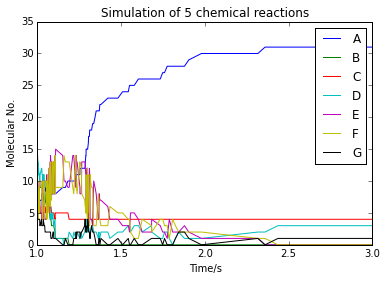

In [8]:
m=np.array(t1_list)
n=np.array(chemical_list)
plt.plot(m,n)
# print(fig)
plt.xlim(t0,t0+2)
plt.title('Simulation of 5 chemical reactions')
plt.xlabel('Time/s')
plt.ylabel('Molecular No.')
plt.legend(['A', 'B', 'C', 'D', 'E', 'F', 'G'])      # plot the figure of stimulation 
plt.show() 